# Examples of data access

The `data/` folder is structured like a python package to make it easier to interact programmatically with the data. Run through this notebook to see how to access various parts of the dataset.

## Importing

If you write a python file from the project root, you can import `data/` as you would any other module:
```python
from data import water, weather
```
but if you're in a different directory within the project (or within the `data/` directory itself) then your script can't see the `data/` directory. You can still import it, with an extra step: reveal the `data/` module to the script with `sys`.

`sys.path` is the list of directories Python searches when you write `import something`. By default this include installed packages and the cwd, maybe some others. `sys.path.insert(0, "path/to/project/root")` prepends the parent directory of `data/` to that list, making it discoverable.

In [ ]:
import sys
sys.path.insert(0, "..")   # replace ".." with the path to the project root, relative or absolute
from data import water, rain, map_overlays

## Water

### Some info on `site_uid`

Much of the data is organized around `site_uid`s. These are unique identifiers for the water sites in the dataset. You can access a complete list of them with

In [2]:
uids = water.get_all_water_sites()
print(uids)

['WQS0003', 'WQS0054', 'WQS0115', 'USGS-06808500', 'WQS0035', 'USGS-05464475', 'WQS0010', 'WQS0081', 'WQS0083', 'WQS0050', 'WQS0005', 'WQS0061', 'USGS-05418110', 'WQS0001', 'WQS0038', 'WQS0013', 'WQS0014', 'WQS0021', 'WQS0114', 'WQS0076', 'WQS0043', 'WQS0024', 'WQS0040', 'WQS0044', 'WQS0048', 'USGS-05464420', 'WQS0051', 'USGS-05465500', 'WQS0058', 'WQS0104', 'USGS-05412500', 'WQS0009', 'WQS0011', 'WQS0032', 'WQS0053', 'WQS0067', 'WQS0064', 'WQS0063', 'WQS0055', 'WQS0006', 'WQS0111', 'WQS0072', 'WQS0033', 'USGS-05418720', 'WQS0080', 'WQS0084', 'USGS-05482500', 'USGS-05455100', 'USGS-05484500', 'WQS0007', 'WQS0025', 'USGS-06603750', 'WQS0027', 'WQS0102', 'WQS0031', 'WQS0023', 'WQS0022', 'WQS0012', 'WQS0037', 'WQS0002', 'WQS0008', 'USGS-05481000', 'USGS-05482000', 'USGS-05482300', 'USGS-05484000', 'WQS0069', 'USGS-05418400', 'USGS-05483600', 'USGS-06604440', 'USGS-06817000', 'WQS0039', 'WQS0046', 'WQS0047', 'WQS0056', 'WQS0070', 'WQS0071', 'WQS0073', 'WQS0074', 'USGS-05480603', 'USGS-0545

There are two patterns all these strings fall into, `WQSxxxx` or `USGS-xxxxxxx` depending on whether it came from a *W*ater *Q*uality *S*ite (State of Iowa mantained) or a USGS site (federally maintained). There are many more sites than are accessible via `water.get_all_water_sites()`, these are the ones that aren't garbage. "Not garbage" means that the site satisfies all of the following:
1. at least $0.5 \%$ of the rows in the site have a non-nan `nitrate_concentration` value
2. site has a total data lifespan of at least $3.92$ years
3. site isn't obviously faulty upon inspecting its total timeseries
4. site doesn't have an absolutely massive drainage basin

Items (1) and (2) are programmatic filters applied in `make_iwqis_data.py` and (3) and (4) are manual filters applied in `make_water.py` using the lists
```python
# known garbage sites that aren't picked up in filtering
KNOWN_BAD = ["WQS0113", "WQS9901", "WQS9903", "WQS9904", "WQS9902", "WQS0091", "WQS0088", "WQS0090", "WQS0045", "WQS0075"]

# these are sites with massive basins, filtering them out
BIG_BASIN = ["WQS0066", "WQS0065", "USGS-05474500", "WQS0020", "USGS-05420500"] 
```

### Water Data

Pick a site, access its full data, display the columns, display info:

In [3]:
uid = uids[0]
water_df = water.get_site_data(uid)
print(water_df.columns)
print(water_df.info())

Index(['site_uid', 'nitrate_con', 'r_exc', 'm_exc', 'temp_water', 'ph',
       'spec_cond', 'diss_oxy_con', 'diss_oxy_sat', 'chloro_v', 'chloro_con',
       'turbi_mean', 'turbi_var', 'turbi_med', 'turbi_bes', 'turbi_min',
       'turbi_max', 'dts_temp_water', 'phosphate_con', 'ph_v2', 'spec_cond_v2',
       'diss_oxy_con_v2', 'diss_oxy_sat_v2', 'turbi_mean_v2'],
      dtype='str')
<class 'pandas.DataFrame'>
DatetimeIndex: 788778 entries, 2012-05-30 21:40:00+00:00 to 2024-12-17 20:15:00+00:00
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   site_uid         788778 non-null  str    
 1   nitrate_con      759021 non-null  float64
 2   r_exc            750226 non-null  float64
 3   m_exc            750226 non-null  float64
 4   temp_water       663493 non-null  float64
 5   ph               662314 non-null  float64
 6   spec_cond        650830 non-null  float64
 7   diss_oxy_con     526438 non-null  float64

Display precomputed statistics about the site:

In [4]:
stats = water.get_stats(uid).iloc[0].to_dict()
for key, val in stats.items():
    print(f"{key} : {val}")

site_uid : WQS0003
nitrate_sparsity : 0.962274556339046
start_date : 2012-05-30 21:40:00+00:00
last_date : 2024-12-17 20:15:00+00:00
lifespan : 12.5501463989657


This is a good site! Long lifespan and really good nitrate sparsity. Display its timeseries:

In [5]:
water.make_site_timeseries_plot(site_uid=uid, value_col="nitrate_con")

We can instead pass a dataframe directly to the plotter. Let's aggregate the data into 1 month increments indexed by the start of the month (`1MS`) using mean:

In [6]:
agg_df = water.aggregate_by_interval(site_uid=uid, interval="1MS", agg_func="mean")
water.make_site_timeseries_plot(df=agg_df)

You can also use `water.make_site_timeseries_plot(site_uid=uid, interval="1MS")` to aggregate and plot directly.

If you want all the data, use `water.get_full_data()`:

In [7]:
full_df = water.get_full_data()

Each `site_uid` comes with a corresponding drainage basin file, which is a GeoPandasFrame accessible with `get_basin(site_uid)`:

In [8]:
basin = water.get_basin(uid)

`GeoDataFrames` have plot methods built in so here's an idea of what the basin looks like, you can see it in context on the map using `widget/`.

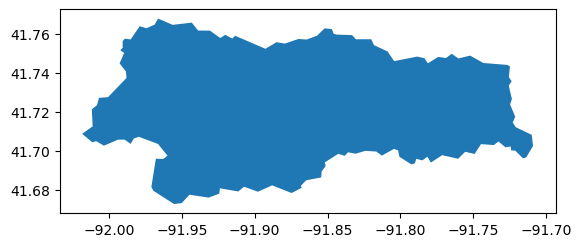

In [9]:
import matplotlib.pyplot as plt

basin.plot()
plt.show()

The rest of the documentation for `water/` can be round in `data/README.md` or by reading `data/water/access.py`.

## Weather

Isaac used Erin's code to cobble together the `make_rain.py` script together with Claude. It seems to have produced a pretty robust downloader. It produces one file `<site_uid>_rain.parquet` per `site_uid` in `water.get_all_sites()`. This can be loaded directly into a `pandas.DataFrame`.

Each of these DataFrames contains rainfall data in $1$ day increments in $4\text{km} \times 4\text{km}$ blocks covering the drainage basin of the specified site.

**The idea is that only rain falling into the drainage basin of a monitoring site will affect the readings of that site.**

In [10]:
rain_data = weather.get_site_rain(site_uid=uid)
print(rain_data.columns)
print(rain_data.info())

Index(['date', 'lon', 'lat', 'precip_in_1d', 'year', 'month', 'day_of_year',
       'week'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 82368 entries, 0 to 82367
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          82368 non-null  datetime64[ms]
 1   lon           82368 non-null  float64       
 2   lat           82368 non-null  float64       
 3   precip_in_1d  82368 non-null  float64       
 4   year          82368 non-null  int32         
 5   month         82368 non-null  int32         
 6   day_of_year   82368 non-null  int32         
 7   week          82368 non-null  int64         
dtypes: datetime64[ms](1), float64(3), int32(3), int64(1)
memory usage: 4.1 MB
None


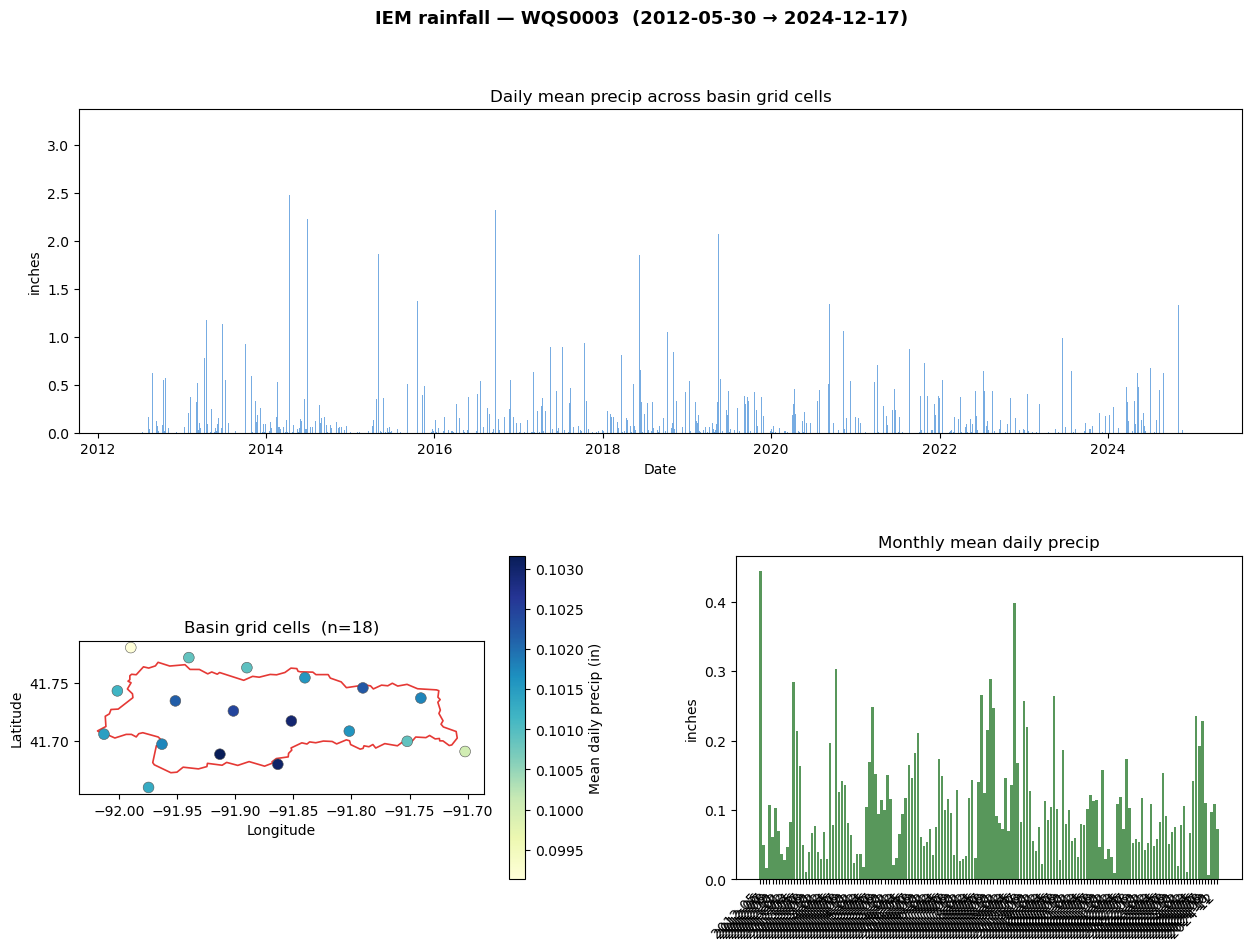

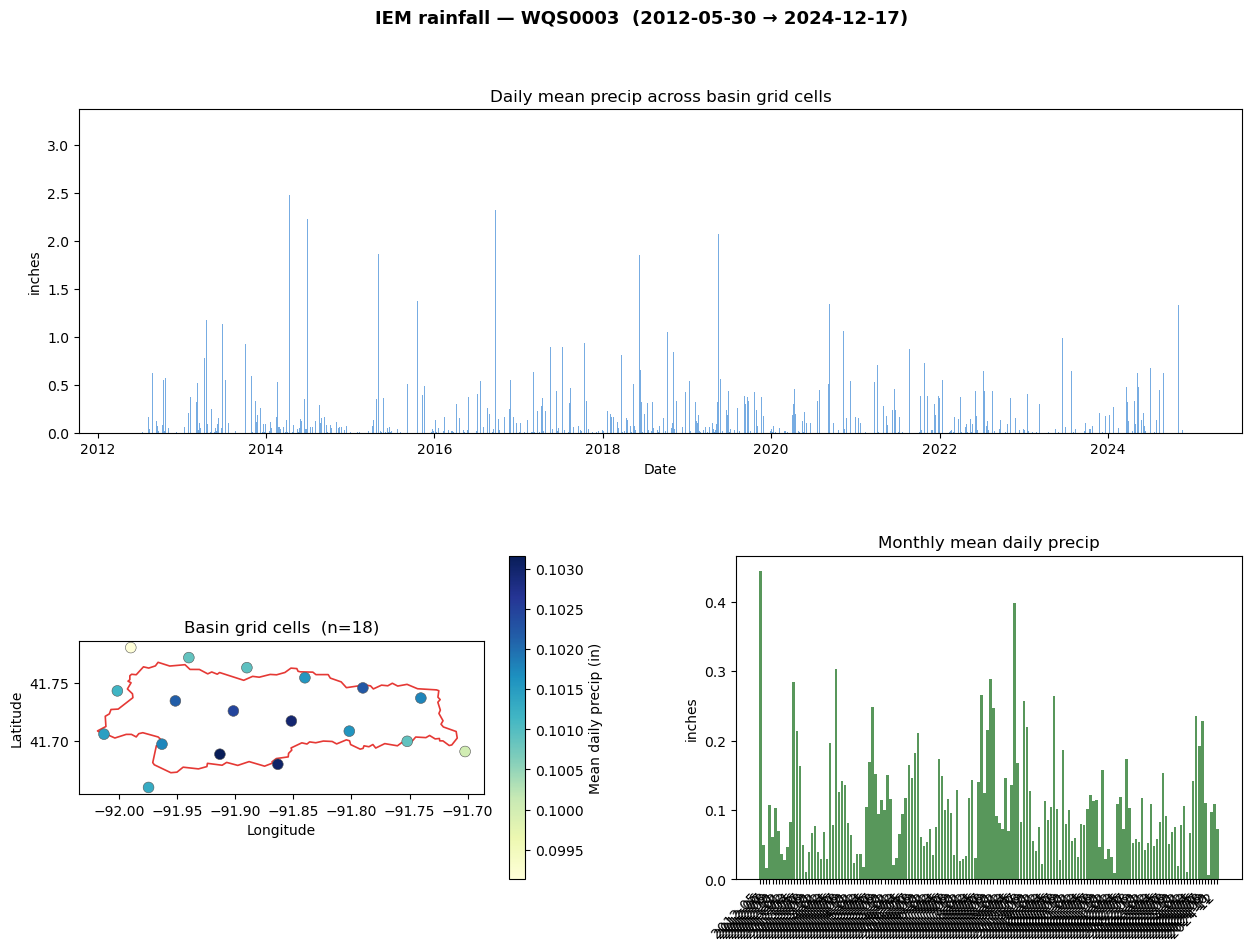

In [12]:
weather.plot_site_rain(site_uid=uid,show=False)